# Baseline LightGBM

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import time
import lightgbm as lgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve().parent

PROCESSED_DIR = (
    PROJECT_DIR /
    'data' /
    'processed'
)

In [3]:
X_train = pd.read_parquet(
    PROCESSED_DIR / "X_train.parquet"
)

X_valid = pd.read_parquet(
    PROCESSED_DIR / "X_valid.parquet"
)

X_test = pd.read_parquet(
    PROCESSED_DIR / "X_test.parquet"
)

y_train = (
    pd.read_parquet(
        PROCESSED_DIR / "y_train.parquet"
    )
    .squeeze()
)

y_valid = (
    pd.read_parquet(
        PROCESSED_DIR / "y_valid.parquet"
    )
    .squeeze()
)

y_test = (
    pd.read_parquet(
        PROCESSED_DIR / "y_test.parquet"
    )
    .squeeze()
)

In [4]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(19127904, 38)
(9976416, 38)
(1629120, 38)


In [5]:
print(X_train.columns.tolist())

['Installation_HasPVSystem', 'Survey_Building_LivingArea', 'Survey_Building_Residents', 'Survey_HeatDistribution_System_FloorHeating', 'Survey_HeatDistribution_System_Radiator', 'Survey_DHW_Production_ByHeatPump', 'Survey_DHW_Production_ByElectricWaterHeater', 'Survey_DHW_Production_BySolar', 'Survey_Installation_HasDryer', 'Survey_Installation_HasFreezer', 'Survey_Installation_HasElectricVehicle', 'Temperature_avg_hourly', 'Humidity_avg_hourly', 'Precipitation_total_hourly', 'WindSpeed_hourly', 'hour', 'day', 'dayofweek', 'month', 'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_4', 'lag_96', 'lag_672', 'rolling_mean_1h', 'rolling_std_1h', 'rolling_mean_24h', 'rolling_std_24h', 'Survey_Building_Type_house', 'Survey_HeatPump_Installation_Type_ground-source', 'season_Spring', 'season_Summer', 'season_Winter']


In [6]:
def smape(y_true, y_pred):

    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    ) / 2

    diff = np.abs(
        y_true - y_pred
    )

    return np.mean(
        np.where(
            denominator == 0,
            0,
            diff / denominator
        )
    ) * 100

In [7]:
start_train = time.time()

baseline_model = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(
    X_train,
    y_train
)

train_time = time.time() - start_train

print(f"Training Time : {train_time:.2f} detik")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.730173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 19127904, number of used features: 38
[LightGBM] [Info] Start training from score 0.302555
Training Time : 41.38 detik


Evaluasi Validation Set

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [9]:
valid_pred = baseline_model.predict(X_valid)

In [10]:
valid_mae = mean_absolute_error(
    y_valid,
    valid_pred
)

valid_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred
    )
)

valid_r2 = r2_score(
    y_valid,
    valid_pred
)

valid_smape = smape(
    y_valid.values,
    valid_pred
)

In [11]:
valid_result = pd.DataFrame({
    'Dataset':['Validation'],
    'MAE':[valid_mae],
    'RMSE':[valid_rmse],
    'SMAPE':[valid_smape],
    'R2':[valid_r2]
})

valid_result

,Dataset,MAE,RMSE,SMAPE,R2
0,Validation,0.125226,0.217974,57.345076,0.684206


Evaluasi Test Set

In [12]:
test_pred = baseline_model.predict(
    X_test
)

In [13]:
test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

test_r2 = r2_score(
    y_test,
    test_pred
)

test_smape = smape(
    y_test.values,
    test_pred
)

In [14]:
test_result = pd.DataFrame({
    'Dataset':['Test'],
    'MAE':[test_mae],
    'RMSE':[test_rmse],
    'SMAPE':[test_smape],
    'R2':[test_r2]
})

test_result

,Dataset,MAE,RMSE,SMAPE,R2
0,Test,0.187378,0.272954,60.542612,0.624751


In [15]:
baseline_result = pd.DataFrame({
    'Model':['LightGBM Baseline'],
    'Valid_MAE':[valid_mae],
    'Valid_RMSE':[valid_rmse],
    'Valid_SMAPE':[valid_smape],
    'Valid_R2':[valid_r2],
    'Test_MAE':[test_mae],
    'Test_RMSE':[test_rmse],
    'Test_SMAPE':[test_smape],
    'Test_R2':[test_r2],
    'Training_Time_sec':[train_time]
})

baseline_result

,Model,Valid_MAE,Valid_RMSE,Valid_SMAPE,Valid_R2,Test_MAE,Test_RMSE,Test_SMAPE,Test_R2,Training_Time_sec
0,LightGBM Baseline,0.125226,0.217974,57.345076,0.684206,0.187378,0.272954,60.542612,0.624751,41.384675


Visualisasi Prediksi vs Aktual

In [16]:
sample = 10000

plot_df = pd.DataFrame({
    'actual': y_test.iloc[:sample],
    'prediction': test_pred[:sample]
})

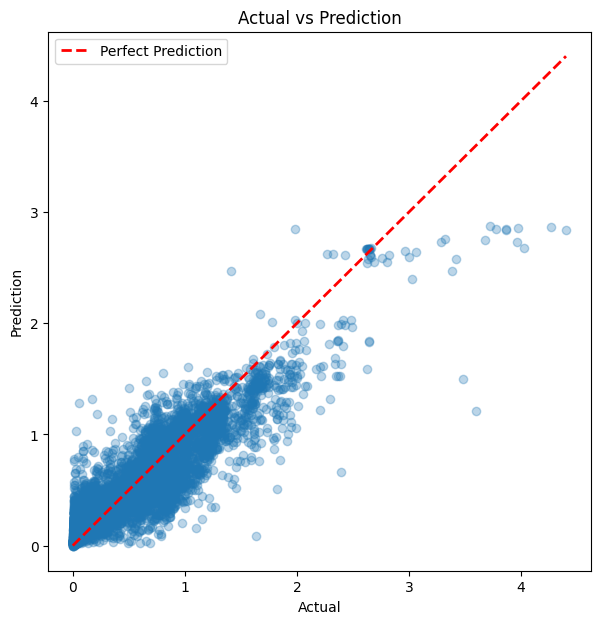

In [17]:
plt.figure(figsize=(7,7))

plt.scatter(
    plot_df['actual'],
    plot_df['prediction'],
    alpha=0.3
)

max_val = max(
    plot_df['actual'].max(),
    plot_df['prediction'].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs Prediction')
plt.legend()

plt.show()

Feature Importance

In [18]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': baseline_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        'importance',
        ascending=False
    )
)

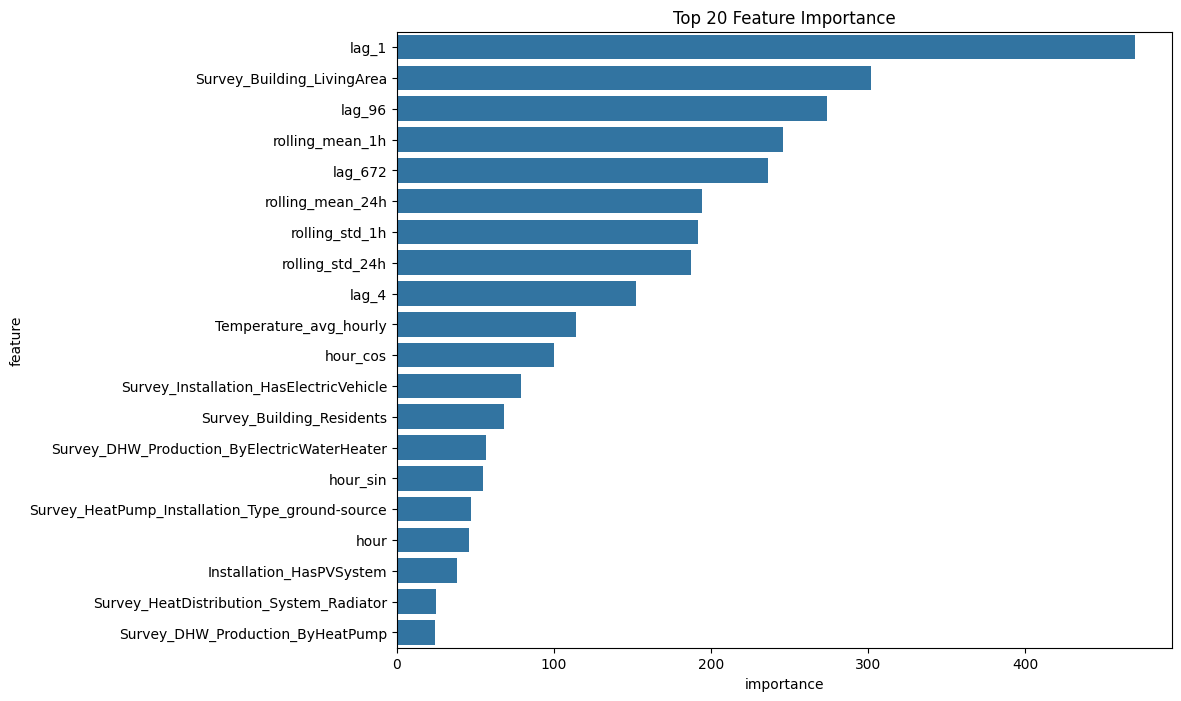

In [19]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x='importance',
    y='feature'
)

plt.title(
    'Top 20 Feature Importance'
)

plt.show()

Random Search LightGBM.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform

In [21]:
param_dist = {
    "n_estimators": randint(300, 1500),
    "learning_rate": uniform(0.01, 0.14),
    "num_leaves": randint(20, 200),
    "max_depth": randint(4, 15),
    "min_child_samples": randint(20, 300),
    "subsample": uniform(0.60, 0.40),
    "colsample_bytree": uniform(0.60, 0.40),
    "reg_alpha": uniform(0, 2),
    "reg_lambda": uniform(0, 2)
}

In [22]:
lgb_random = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    random_state=42,
    n_jobs=-1
)

In [23]:
random_search = RandomizedSearchCV(
    estimator=lgb_random,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [24]:
X_train_tune = X_train.sample(
    n=1_000_000,
    random_state=42
)

y_train_tune = y_train.loc[
    X_train_tune.index
]

In [25]:
X_train_tune.shape

(1000000, 38)

In [26]:
y_train_tune.shape

(1000000,)

In [27]:
import time

start = time.time()

random_search.fit(
    X_train_tune,
    y_train_tune
)

random_time = (
    time.time() - start
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053056 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 38
[LightGBM] [Info] Start training from score 0.302439


In [28]:
random_search.best_params_

{'colsample_bytree': 0.7232243167409557,
 'learning_rate': 0.0859556322776859,
 'max_depth': 14,
 'min_child_samples': 41,
 'n_estimators': 1049,
 'num_leaves': 177,
 'reg_alpha': 1.9460211095048912,
 'reg_lambda': 0.7861954493335208,
 'subsample': 0.9568186220708453}

In [29]:
random_search.best_score_

-0.20891362136680747

In [30]:
best_random = random_search.best_estimator_

In [31]:
random_search.best_params_
random_search.best_score_
random_time

6409.138122081757

In [32]:
import time

start = time.time()

best_random.fit(
    X_train,
    y_train
)

random_train_time = (
    time.time() - start
)

print(
    f"Training Time : {random_train_time:.2f} sec"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.907763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 19127904, number of used features: 38
[LightGBM] [Info] Start training from score 0.302555
Training Time : 377.56 sec


In [33]:
valid_pred_random = best_random.predict(
    X_valid
)

In [34]:
test_pred_random = best_random.predict(
    X_test
)

In [35]:
valid_mae_random = mean_absolute_error(
    y_valid,
    valid_pred_random
)

valid_rmse_random = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred_random
    )
)

valid_r2_random = r2_score(
    y_valid,
    valid_pred_random
)

valid_smape_random = smape(
    y_valid.values,
    valid_pred_random
)

In [36]:
test_mae_random = mean_absolute_error(
    y_test,
    test_pred_random
)

test_rmse_random = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred_random
    )
)

test_r2_random = r2_score(
    y_test,
    test_pred_random
)

test_smape_random = smape(
    y_test.values,
    test_pred_random
)

In [37]:
random_result = pd.DataFrame({
    'Model':['LightGBM Random Search'],
    'Valid_MAE':[valid_mae_random],
    'Valid_RMSE':[valid_rmse_random],
    'Valid_SMAPE':[valid_smape_random],
    'Valid_R2':[valid_r2_random],
    'Test_MAE':[test_mae_random],
    'Test_RMSE':[test_rmse_random],
    'Test_SMAPE':[test_smape_random],
    'Test_R2':[test_r2_random],
    'Tuning_Time_sec':[random_time],
    'Training_Time_sec':[random_train_time]
})

random_result

,Model,Valid_MAE,Valid_RMSE,Valid_SMAPE,Valid_R2,Test_MAE,Test_RMSE,Test_SMAPE,Test_R2,Tuning_Time_sec,Training_Time_sec
0,LightGBM Random Search,0.112103,0.198789,54.371241,0.737349,0.166687,0.249194,56.274997,0.687235,6409.138122,377.555327


In [38]:
comparison = pd.concat(
    [
        baseline_result,
        random_result
    ],
    ignore_index=True
)

comparison

,Model,Valid_MAE,Valid_RMSE,Valid_SMAPE,Valid_R2,Test_MAE,Test_RMSE,Test_SMAPE,Test_R2,Training_Time_sec,Tuning_Time_sec
0,LightGBM Baseline,0.125226,0.217974,57.345076,0.684206,0.187378,0.272954,60.542612,0.624751,41.384675,NaN
1,LightGBM Random Search,0.112103,0.198789,54.371241,0.737349,0.166687,0.249194,56.274997,0.687235,377.555327,6409.138122


Bayesian Optimization LightGBM.

In [39]:
import sys
print(sys.executable)

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\python.exe


In [40]:
!{sys.executable} -m pip install bayesian-optimization


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import numpy as np
import time

In [42]:
X_train_tune = X_train.sample(
    n=1000000,
    random_state=42
)

y_train_tune = y_train.loc[
    X_train_tune.index
]

In [43]:
def lgb_eval(
    n_estimators,
    learning_rate,
    num_leaves,
    max_depth,
    min_child_samples,
    subsample,
    colsample_bytree,
    reg_alpha,
    reg_lambda
):

    params = {

        "objective": "regression",
        "boosting_type": "gbdt",
        "random_state": 42,
        "n_jobs": -1,

        "n_estimators": int(n_estimators),

        "learning_rate": learning_rate,

        "num_leaves": int(num_leaves),

        "max_depth": int(max_depth),

        "min_child_samples": int(min_child_samples),

        "subsample": subsample,

        "colsample_bytree": colsample_bytree,

        "reg_alpha": reg_alpha,

        "reg_lambda": reg_lambda
    }


    model = lgb.LGBMRegressor(
        **params
    )


    model.fit(
        X_train_tune,
        y_train_tune
    )


    pred = model.predict(
        X_valid
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            pred
        )
    )

    return -rmse

In [44]:
pbounds = {

    "n_estimators": (300,1500),

    "learning_rate": (0.01,0.15),

    "num_leaves": (20,200),

    "max_depth": (4,15),

    "min_child_samples": (20,300),

    "subsample": (0.6,1.0),

    "colsample_bytree": (0.6,1.0),

    "reg_alpha": (0,2),

    "reg_lambda": (0,2)

}

In [45]:
optimizer = BayesianOptimization(
    f=lgb_eval,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

In [46]:
start = time.time()


optimizer.maximize(
    init_points=10,
    n_iter=40
)


bayes_time = time.time() - start


print(
    f"Bayesian Training Time : {bayes_time:.2f} detik"
)

|   iter    |  target   | n_esti... | learni... | num_le... | max_depth | min_ch... | subsample | colsam... | reg_alpha | reg_la... |
-------------------------------------------------------------------------------------------------------------------------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.153631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 38
[LightGBM] [Info] Start training from score 0.302439
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
| 1         | -0.208097 | 749.44814 | 0.1431000 | 151.75890 | 10.585243 | 63.685219 | 0.6623978 | 0.6232334 | 1.7323522 | 1.2022300 |
[LightGBM] [Info] Auto-choosi

In [47]:
optimizer.max

{'target': -0.2065233731894754,
 'params': {'n_estimators': 1149.2404533927333,
  'learning_rate': 0.07610270299676508,
  'num_leaves': 196.3714878497074,
  'max_depth': 10.037899811570853,
  'min_child_samples': 74.00481905115979,
  'subsample': 0.8811739907494118,
  'colsample_bytree': 0.8267713906115743,
  'reg_alpha': 0.7654570903714264,
  'reg_lambda': 1.7627639004972737}}

In [48]:
best_params = optimizer.max['params']

best_params

{'n_estimators': 1149.2404533927333,
 'learning_rate': 0.07610270299676508,
 'num_leaves': 196.3714878497074,
 'max_depth': 10.037899811570853,
 'min_child_samples': 74.00481905115979,
 'subsample': 0.8811739907494118,
 'colsample_bytree': 0.8267713906115743,
 'reg_alpha': 0.7654570903714264,
 'reg_lambda': 1.7627639004972737}

In [49]:
best_params['num_leaves'] = int(best_params['num_leaves'])
best_params['max_depth'] = int(best_params['max_depth'])
best_params['min_child_samples'] = int(best_params['min_child_samples'])
best_params['n_estimators'] = int(best_params['n_estimators'])

In [50]:
best_params['objective']='regression'
best_params['boosting_type']='gbdt'
best_params['random_state']=42
best_params['n_jobs']=-1

In [51]:
best_bayes = lgb.LGBMRegressor(
    **best_params
)

In [52]:
start = time.time()

best_bayes.fit(
    X_train,
    y_train
)

bayes_train_time = (
    time.time() - start
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.784959 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 19127904, number of used features: 38
[LightGBM] [Info] Start training from score 0.302555


In [53]:
y_pred_valid_bayes = best_bayes.predict(X_valid)
y_pred_test_bayes = best_bayes.predict(X_test)

In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

def smape(y_true, y_pred):
    return (
        100
        * np.mean(
            2
            * np.abs(y_pred - y_true)
            / (
                np.abs(y_true)
                + np.abs(y_pred)
                + 1e-8
            )
        )
    )

In [55]:
valid_mae_bayes = mean_absolute_error(
    y_valid,
    y_pred_valid_bayes
)

valid_rmse_bayes = np.sqrt(
    mean_squared_error(
        y_valid,
        y_pred_valid_bayes
    )
)

valid_smape_bayes = smape(
    y_valid,
    y_pred_valid_bayes
)

valid_r2_bayes = r2_score(
    y_valid,
    y_pred_valid_bayes
)

In [56]:
test_mae_bayes = mean_absolute_error(
    y_test,
    y_pred_test_bayes
)

test_rmse_bayes = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test_bayes
    )
)

test_smape_bayes = smape(
    y_test,
    y_pred_test_bayes
)

test_r2_bayes = r2_score(
    y_test,
    y_pred_test_bayes
)

In [57]:
bayes_result = pd.DataFrame({
    'Model':['LightGBM Bayesian'],
    'Valid_MAE':[valid_mae_bayes],
    'Valid_RMSE':[valid_rmse_bayes],
    'Valid_SMAPE':[valid_smape_bayes],
    'Valid_R2':[valid_r2_bayes],
    'Test_MAE':[test_mae_bayes],
    'Test_RMSE':[test_rmse_bayes],
    'Test_SMAPE':[test_smape_bayes],
    'Test_R2':[test_r2_bayes],
    'Training_Time_sec':[bayes_train_time],
    'Tuning_Time_sec':[bayes_time]
})

In [58]:
comparison = pd.concat(
    [
        baseline_result,
        random_result,
        bayes_result
    ],
    ignore_index=True
)

comparison

,Model,Valid_MAE,Valid_RMSE,Valid_SMAPE,Valid_R2,Test_MAE,Test_RMSE,Test_SMAPE,Test_R2,Training_Time_sec,Tuning_Time_sec
0,LightGBM Baseline,0.125226,0.217974,57.345076,0.684206,0.187378,0.272954,60.542612,0.624751,41.384675,NaN
1,LightGBM Random Search,0.112103,0.198789,54.371241,0.737349,0.166687,0.249194,56.274997,0.687235,377.555327,6409.138122
2,LightGBM Bayesian,0.112229,0.199165,54.357783,0.736356,0.166864,0.249666,56.316618,0.686049,536.753767,7214.093614


Optuna Optimization 

In [59]:
!pip install optuna


[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: C:\Users\ahmad\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [60]:
import optuna
import lightgbm as lgb
import numpy as np
import time

from sklearn.metrics import mean_squared_error

In [61]:
X_train_tune = X_train.sample(
    n=1000000,
    random_state=42
)

y_train_tune = y_train.loc[
    X_train_tune.index
]

In [62]:
def objective(trial):

    params = {

        "objective": "regression",

        "boosting_type": "gbdt",

        "metric": "rmse",

        "random_state": 42,

        "n_jobs": -1,


        "n_estimators":
            trial.suggest_int(
                "n_estimators",
                300,
                1500
            ),


        "learning_rate":
            trial.suggest_float(
                "learning_rate",
                0.01,
                0.15
            ),


        "num_leaves":
            trial.suggest_int(
                "num_leaves",
                20,
                200
            ),


        "max_depth":
            trial.suggest_int(
                "max_depth",
                4,
                15
            ),


        "min_child_samples":
            trial.suggest_int(
                "min_child_samples",
                20,
                300
            ),


        "subsample":
            trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),


        "colsample_bytree":
            trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),


        "reg_alpha":
            trial.suggest_float(
                "reg_alpha",
                0,
                2
            ),


        "reg_lambda":
            trial.suggest_float(
                "reg_lambda",
                0,
                2
            )
    }


    model = lgb.LGBMRegressor(
        **params
    )


    model.fit(
        X_train_tune,
        y_train_tune
    )


    pred = model.predict(
        X_valid
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            pred
        )
    )


    return rmse

In [63]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=42
    )
)

[I 2026-08-07 19:13:33,642] A new study created in memory with name: no-name-7a0b97a5-a6d2-4b73-b484-06a2f3700c92


In [64]:
n_trials = 50


start = time.time()


study.optimize(
    objective,
    n_trials=n_trials
)


optuna_time = (
    time.time() - start
)


print(
    f"Optuna Training Time : {optuna_time:.2f} detik"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054509 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 38
[LightGBM] [Info] Start training from score 0.302439
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-08-07 19:15:41,352] Trial 0 finished with value: 0.20782442066137763 and parameters: {'n_estimators': 749, 'learning_rate': 0.14310000289738825, 'num_leaves': 152, 'max_depth': 11, 'min_child_samples': 63, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 0.20782442066137763.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 38
[LightGBM] [Info] Start training from score 0.302439


[I 2026-08-07 19:22:15,724] Trial 1 finished with value: 0.20954111082003937 and parameters: {'n_estimators': 1150, 'learning_rate': 0.012881829201412343, 'num_leaves': 195, 'max_depth': 13, 'min_child_samples': 79, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 1.0495128632644757}. Best is trial 0 with value: 0.20782442066137763.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 38
[LightGBM] [Info] Start training from score 0.302439
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 38
[LightGBM] [Info] Start training from score 0.302439
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-08-07 22:43:56,988] Trial 48 finished with value: 0.2072282706274203 and parameters: {'n_estimators': 750, 'learning_rate': 0.09014711109494992, 'num_leaves': 157, 'max_depth': 11, 'min_child_samples': 21, 'subsample': 0.9776547901266519, 'colsample_bytree': 0.8565192053750045, 'reg_alpha': 0.10704179453837448, 'reg_lambda': 0.5705344184003112}. Best is trial 45 with value: 0.20679733058202596.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050004 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3025
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 38
[LightGBM] [Info] Start training from score 0.302439
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-08-07 22:45:07,254] Trial 49 finished with value: 0.2075311347724054 and parameters: {'n_estimators': 604, 'learning_rate': 0.10303298564638597, 'num_leaves': 184, 'max_depth': 12, 'min_child_samples': 29, 'subsample': 0.8144704680781203, 'colsample_bytree': 0.8344958569104564, 'reg_alpha': 0.4585097610946467, 'reg_lambda': 0.735192367612579}. Best is trial 45 with value: 0.20679733058202596.


Optuna Training Time : 12693.60 detik


In [65]:
study.best_params

{'n_estimators': 863,
 'learning_rate': 0.1118754533009096,
 'num_leaves': 155,
 'max_depth': 12,
 'min_child_samples': 20,
 'subsample': 0.9750648387141824,
 'colsample_bytree': 0.8098026936887558,
 'reg_alpha': 0.4083293170868678,
 'reg_lambda': 1.6233660832287782}

In [66]:
study.best_value

0.20679733058202596

In [67]:
optuna_time

12693.599058389664

In [68]:
best_optuna_params = study.best_params

best_optuna_params['objective'] = 'regression'
best_optuna_params['boosting_type'] = 'gbdt'
best_optuna_params['random_state'] = 42
best_optuna_params['n_jobs'] = -1

best_optuna = lgb.LGBMRegressor(
    **best_optuna_params
)

In [69]:
start = time.time()

best_optuna.fit(
    X_train,
    y_train
)

optuna_train_time = (
    time.time() - start
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.752936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 19127904, number of used features: 38
[LightGBM] [Info] Start training from score 0.302555


In [70]:
y_pred_valid_optuna = best_optuna.predict(X_valid)
y_pred_test_optuna = best_optuna.predict(X_test)

In [71]:
valid_mae_optuna = mean_absolute_error(
    y_valid,
    y_pred_valid_optuna
)

valid_rmse_optuna = np.sqrt(
    mean_squared_error(
        y_valid,
        y_pred_valid_optuna
    )
)

valid_smape_optuna = smape(
    y_valid,
    y_pred_valid_optuna
)

valid_r2_optuna = r2_score(
    y_valid,
    y_pred_valid_optuna
)

In [72]:
test_mae_optuna = mean_absolute_error(
    y_test,
    y_pred_test_optuna
)

test_rmse_optuna = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test_optuna
    )
)

test_smape_optuna = smape(
    y_test,
    y_pred_test_optuna
)

test_r2_optuna = r2_score(
    y_test,
    y_pred_test_optuna
)

In [73]:
optuna_result = pd.DataFrame({
    'Model':['LightGBM Optuna'],
    'Valid_MAE':[valid_mae_optuna],
    'Valid_RMSE':[valid_rmse_optuna],
    'Valid_SMAPE':[valid_smape_optuna],
    'Valid_R2':[valid_r2_optuna],
    'Test_MAE':[test_mae_optuna],
    'Test_RMSE':[test_rmse_optuna],
    'Test_SMAPE':[test_smape_optuna],
    'Test_R2':[test_r2_optuna],
    'Training_Time_sec':[optuna_train_time],
    'Tuning_Time_sec':[optuna_time]
})

In [74]:
comparison = pd.concat(
    [
        baseline_result,
        random_result,
        bayes_result,
        optuna_result
    ],
    ignore_index=True
)

comparison

,Model,Valid_MAE,Valid_RMSE,Valid_SMAPE,Valid_R2,Test_MAE,Test_RMSE,Test_SMAPE,Test_R2,Training_Time_sec,Tuning_Time_sec
0,LightGBM Baseline,0.125226,0.217974,57.345076,0.684206,0.187378,0.272954,60.542612,0.624751,41.384675,NaN
1,LightGBM Random Search,0.112103,0.198789,54.371241,0.737349,0.166687,0.249194,56.274997,0.687235,377.555327,6409.138122
2,LightGBM Bayesian,0.112229,0.199165,54.357783,0.736356,0.166864,0.249666,56.316618,0.686049,536.753767,7214.093614
3,LightGBM Optuna,0.112050,0.198972,54.396079,0.736865,0.166517,0.249388,56.206013,0.686750,270.631166,12693.599058


In [75]:
comparison['Training_Time_min'] = (
    comparison['Training_Time_sec'] / 60
)

comparison['Tuning_Time_min'] = (
    comparison['Tuning_Time_sec'] / 60
)

comparison[
    [
        'Model',
        'Training_Time_min',
        'Tuning_Time_min'
    ]
].round(2)

,Model,Training_Time_min,Tuning_Time_min
0,LightGBM Baseline,0.69,NaN
1,LightGBM Random Search,6.29,106.82
2,LightGBM Bayesian,8.95,120.23
3,LightGBM Optuna,4.51,211.56


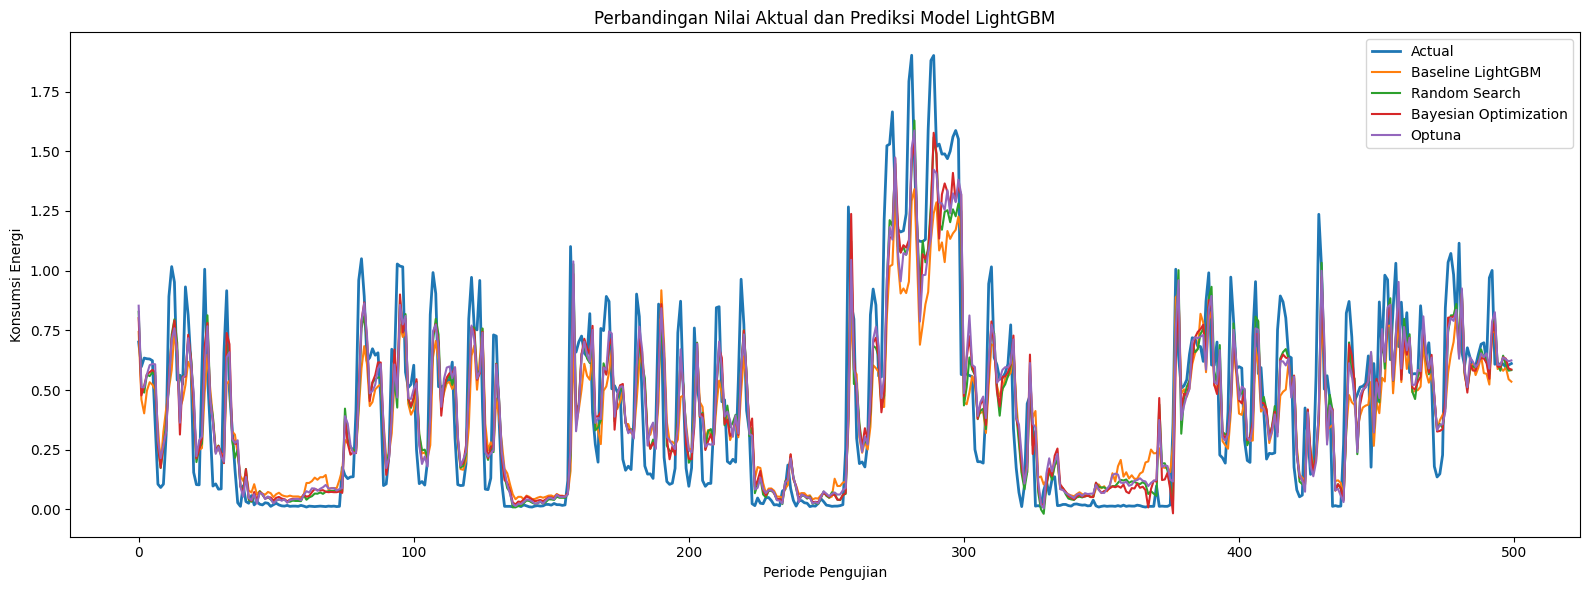

In [76]:
import matplotlib.pyplot as plt
import pandas as pd

sample = 500

test_period = range(sample)

plot_df = pd.DataFrame({
    "Period": test_period,
    "Actual": y_test.iloc[:sample].values,
    "Baseline": test_pred[:sample],
    "Random Search": test_pred_random[:sample],
    "Bayesian Optimization": y_pred_test_bayes[:sample],
    "Optuna": y_pred_test_optuna[:sample]
})


plt.figure(figsize=(16,6))

plt.plot(
    plot_df["Period"],
    plot_df["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_df["Period"],
    plot_df["Baseline"],
    label="Baseline LightGBM"
)

plt.plot(
    plot_df["Period"],
    plot_df["Random Search"],
    label="Random Search"
)

plt.plot(
    plot_df["Period"],
    plot_df["Bayesian Optimization"],
    label="Bayesian Optimization"
)

plt.plot(
    plot_df["Period"],
    plot_df["Optuna"],
    label="Optuna"
)


plt.xlabel("Periode Pengujian")
plt.ylabel("Konsumsi Energi")

plt.title(
    "Perbandingan Nilai Aktual dan Prediksi Model LightGBM"
)

plt.legend()

plt.tight_layout()

plt.show()

Uji Stabilitas Model

In [77]:
n_cv_sample = 500_000

In [78]:
X_cv = X_train.sample(
    n=500_000,
    random_state=42
)

y_cv = y_train.loc[X_cv.index]

print(X_cv.shape)
print(y_cv.shape)

(500000, 38)
(500000,)


In [79]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np
import time

In [80]:
from sklearn.metrics import make_scorer
import numpy as np

def smape(y_true, y_pred):
    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    ) / 2

    diff = np.abs(
        y_true - y_pred
    )

    return np.mean(
        np.where(
            denominator == 0,
            0,
            diff / denominator
        )
    ) * 100

In [81]:
smape_scorer = make_scorer(
    smape,
    greater_is_better=False
)

In [82]:
def evaluate_stability(
    model,
    X,
    y,
    model_name
):

    start = time.time()

    cv_result = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring={
            'mae':
                'neg_mean_absolute_error',

            'rmse':
                'neg_root_mean_squared_error',

            'r2':
                'r2',

            'smape':
                smape_scorer
        },
        n_jobs=-1,
        return_train_score=False
    )

    total_time = time.time() - start

    result = pd.DataFrame({
        'Model': [model_name],

        'MAE_Mean': [
            -cv_result['test_mae'].mean()
        ],
        'MAE_STD': [
            cv_result['test_mae'].std()
        ],

        'RMSE_Mean': [
            -cv_result['test_rmse'].mean()
        ],
        'RMSE_STD': [
            cv_result['test_rmse'].std()
        ],

        'SMAPE_Mean': [
            -cv_result['test_smape'].mean()
        ],
        'SMAPE_STD': [
            cv_result['test_smape'].std()
        ],

        'R2_Mean': [
            cv_result['test_r2'].mean()
        ],
        'R2_STD': [
            cv_result['test_r2'].std()
        ],

        'CV_Time_sec': [
            total_time
        ]
    })

    return result

In [83]:
stability_baseline = evaluate_stability(
    baseline_model,
    X_cv,
    y_cv,
    'LightGBM Baseline'
)

stability_baseline

,Model,MAE_Mean,MAE_STD,RMSE_Mean,RMSE_STD,SMAPE_Mean,SMAPE_STD,R2_Mean,R2_STD,CV_Time_sec
0,LightGBM Baseline,0.131126,0.000329,0.226177,0.001059,54.54879,0.104731,0.689441,0.003393,9.794333


In [84]:
stability_random = evaluate_stability(
    best_random,
    X_cv,
    y_cv,
    'LightGBM Random Search'
)

stability_random

,Model,MAE_Mean,MAE_STD,RMSE_Mean,RMSE_STD,SMAPE_Mean,SMAPE_STD,R2_Mean,R2_STD,CV_Time_sec
0,LightGBM Random Search,0.121168,0.000193,0.213848,0.000676,52.187301,0.167713,0.722369,0.00338,87.230586


In [85]:
stability_bayes = evaluate_stability(
    best_bayes,
    X_cv,
    y_cv,
    'LightGBM Bayesian'
)

stability_bayes

,Model,MAE_Mean,MAE_STD,RMSE_Mean,RMSE_STD,SMAPE_Mean,SMAPE_STD,R2_Mean,R2_STD,CV_Time_sec
0,LightGBM Bayesian,0.121828,0.000149,0.214612,0.000885,52.573807,0.16943,0.720389,0.002699,124.694693


In [86]:
stability_optuna = evaluate_stability(
    best_optuna,
    X_cv,
    y_cv,
    'LightGBM Optuna'
)

stability_optuna    

,Model,MAE_Mean,MAE_STD,RMSE_Mean,RMSE_STD,SMAPE_Mean,SMAPE_STD,R2_Mean,R2_STD,CV_Time_sec
0,LightGBM Optuna,0.121731,0.000201,0.214548,0.000469,52.386942,0.167453,0.72055,0.003116,58.282829


In [87]:
stability_comparison = pd.concat(
    [
        stability_baseline,
        stability_random,
        stability_bayes,
        stability_optuna
    ],
    ignore_index=True
)

stability_comparison['CV_Time_min'] = (
    stability_comparison['CV_Time_sec'] / 60
).round(2)

stability_comparison = (
    stability_comparison
    .round(4)
)

stability_comparison

,Model,MAE_Mean,MAE_STD,RMSE_Mean,RMSE_STD,SMAPE_Mean,SMAPE_STD,R2_Mean,R2_STD,CV_Time_sec,CV_Time_min
0,LightGBM Baseline,0.1311,0.0003,0.2262,0.0011,54.5488,0.1047,0.6894,0.0034,9.7943,0.16
1,LightGBM Random Search,0.1212,0.0002,0.2138,0.0007,52.1873,0.1677,0.7224,0.0034,87.2306,1.45
2,LightGBM Bayesian,0.1218,0.0001,0.2146,0.0009,52.5738,0.1694,0.7204,0.0027,124.6947,2.08
3,LightGBM Optuna,0.1217,0.0002,0.2145,0.0005,52.3869,0.1675,0.7206,0.0031,58.2828,0.97


In [88]:
stability_comparison.sort_values(
    by='R2_STD'
)

,Model,MAE_Mean,MAE_STD,RMSE_Mean,RMSE_STD,SMAPE_Mean,SMAPE_STD,R2_Mean,R2_STD,CV_Time_sec,CV_Time_min
2,LightGBM Bayesian,0.1218,0.0001,0.2146,0.0009,52.5738,0.1694,0.7204,0.0027,124.6947,2.08
3,LightGBM Optuna,0.1217,0.0002,0.2145,0.0005,52.3869,0.1675,0.7206,0.0031,58.2828,0.97
0,LightGBM Baseline,0.1311,0.0003,0.2262,0.0011,54.5488,0.1047,0.6894,0.0034,9.7943,0.16
1,LightGBM Random Search,0.1212,0.0002,0.2138,0.0007,52.1873,0.1677,0.7224,0.0034,87.2306,1.45


In [89]:
stability_comparison.sort_values(
    by='RMSE_STD'
)

,Model,MAE_Mean,MAE_STD,RMSE_Mean,RMSE_STD,SMAPE_Mean,SMAPE_STD,R2_Mean,R2_STD,CV_Time_sec,CV_Time_min
3,LightGBM Optuna,0.1217,0.0002,0.2145,0.0005,52.3869,0.1675,0.7206,0.0031,58.2828,0.97
1,LightGBM Random Search,0.1212,0.0002,0.2138,0.0007,52.1873,0.1677,0.7224,0.0034,87.2306,1.45
2,LightGBM Bayesian,0.1218,0.0001,0.2146,0.0009,52.5738,0.1694,0.7204,0.0027,124.6947,2.08
0,LightGBM Baseline,0.1311,0.0003,0.2262,0.0011,54.5488,0.1047,0.6894,0.0034,9.7943,0.16


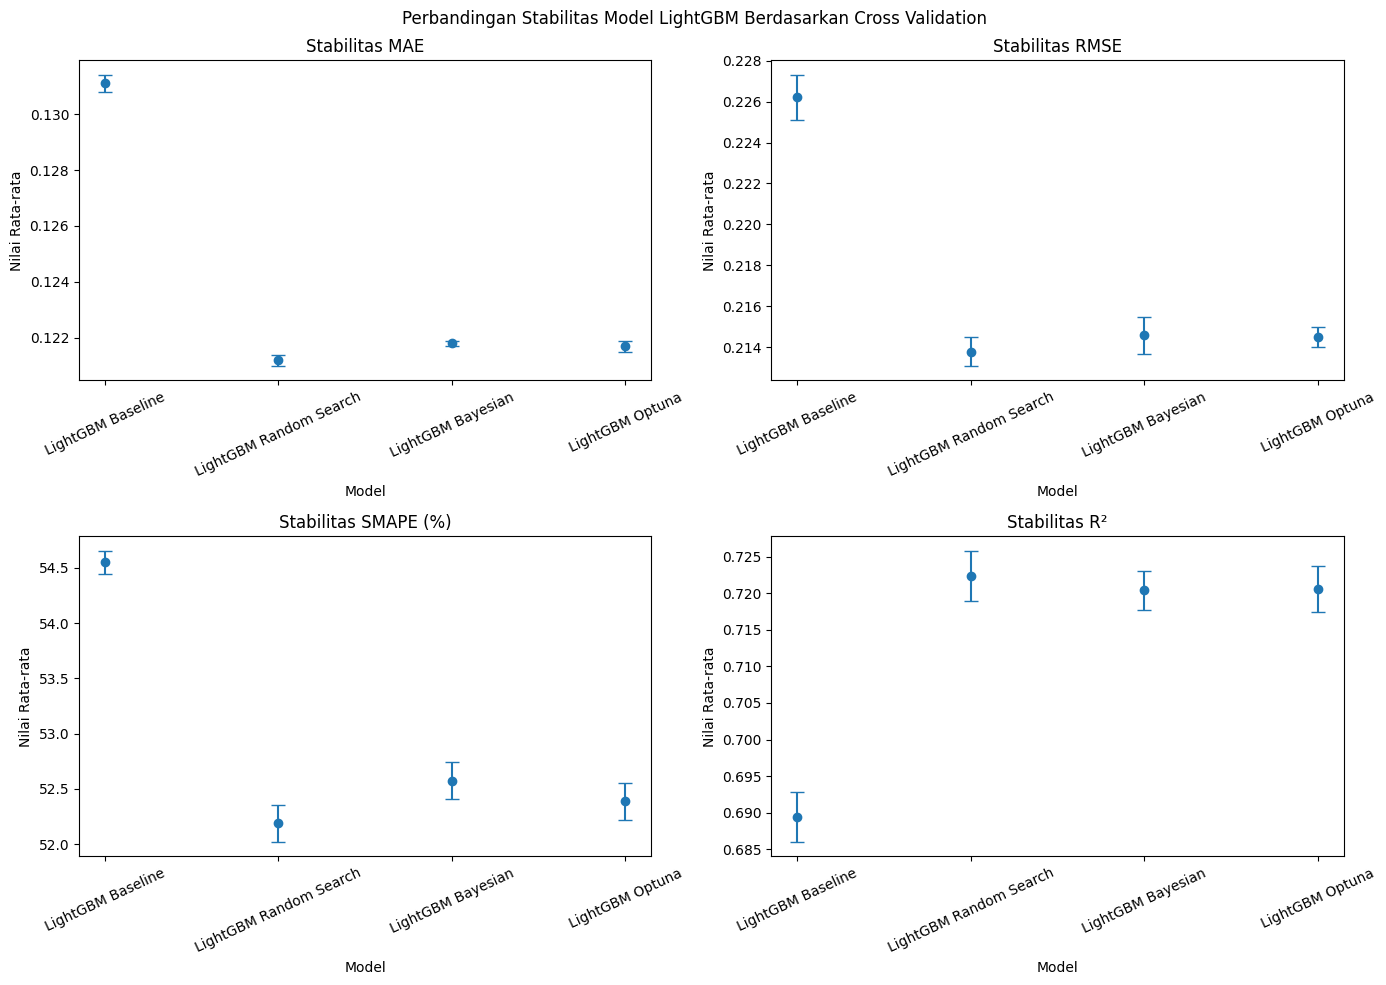

In [90]:
import matplotlib.pyplot as plt

metrics = [
    ("MAE_Mean", "MAE_STD", "Stabilitas MAE"),
    ("RMSE_Mean", "RMSE_STD", "Stabilitas RMSE"),
    ("SMAPE_Mean", "SMAPE_STD", "Stabilitas SMAPE (%)"),
    ("R2_Mean", "R2_STD", "Stabilitas R²")
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(14,10)
)

for ax, (mean_col, std_col, title) in zip(axes.flatten(), metrics):

    ax.errorbar(
        stability_comparison["Model"],
        stability_comparison[mean_col],
        yerr=stability_comparison[std_col],
        fmt='o',
        capsize=5
    )

    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel("Nilai Rata-rata")

    ax.tick_params(
        axis='x',
        rotation=25
    )

plt.suptitle(
    "Perbandingan Stabilitas Model LightGBM Berdasarkan Cross Validation"
)

plt.tight_layout()

plt.show()

Actual vs Prediction

In [91]:
import matplotlib.pyplot as plt
import numpy as np


def plot_actual_prediction(
    y_true,
    y_pred,
    title
):

    sample_size = 10000

    idx = np.random.choice(
        len(y_true),
        sample_size,
        replace=False
    )

    y_true_plot = y_true.iloc[idx]
    y_pred_plot = y_pred[idx]


    plt.figure(figsize=(8,8))


    plt.scatter(
        y_true_plot,
        y_pred_plot,
        alpha=0.4
    )


    plt.plot(
        [
            y_true_plot.min(),
            y_true_plot.max()
        ],
        [
            y_true_plot.min(),
            y_true_plot.max()
        ],
        'r--',
        linewidth=2
    )


    plt.xlabel(
        "Actual Consumption"
    )

    plt.ylabel(
        "Predicted Consumption"
    )


    plt.title(
        title
    )


    plt.show()

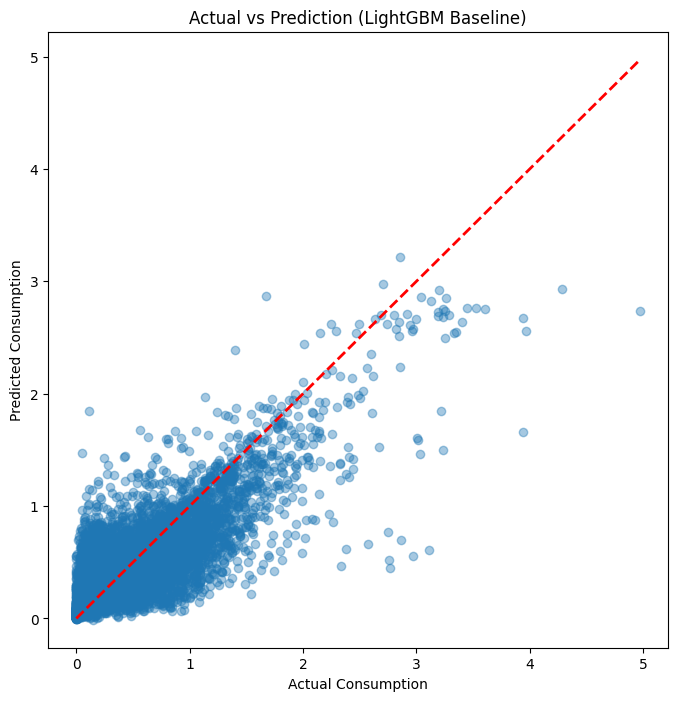

In [92]:
plot_actual_prediction(
    y_test,
    test_pred,
    "Actual vs Prediction (LightGBM Baseline)"
)

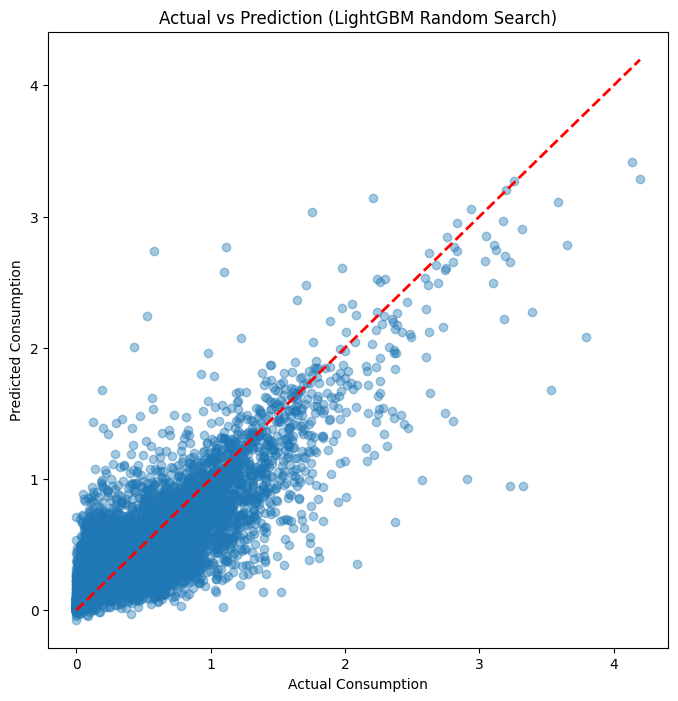

In [93]:
plot_actual_prediction(
    y_test,
    test_pred_random,
    "Actual vs Prediction (LightGBM Random Search)"
)

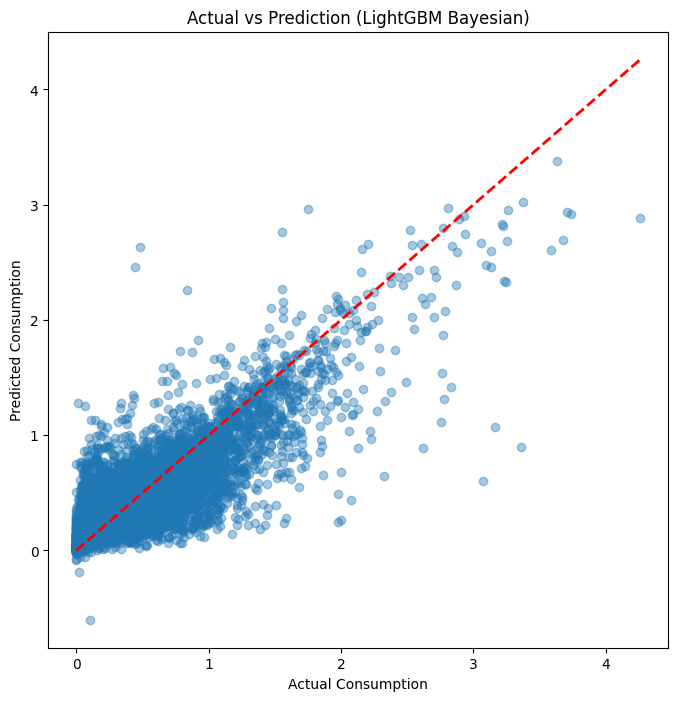

In [94]:
plot_actual_prediction(
    y_test,
    y_pred_test_bayes,
    "Actual vs Prediction (LightGBM Bayesian)"
)

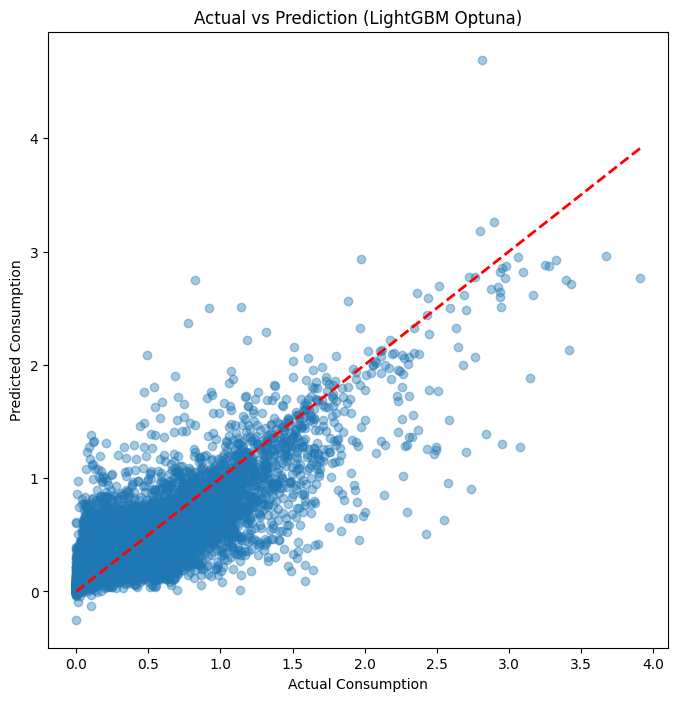

In [95]:
plot_actual_prediction(
    y_test,
    y_pred_test_optuna,
    "Actual vs Prediction (LightGBM Optuna)"
)

Feature Importance 

In [96]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_feature_importance(model, feature_names, title, top_n=20):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })


    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(top_n)


    plt.figure(figsize=(10,8))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.title(title)

    plt.show()


    return importance_df

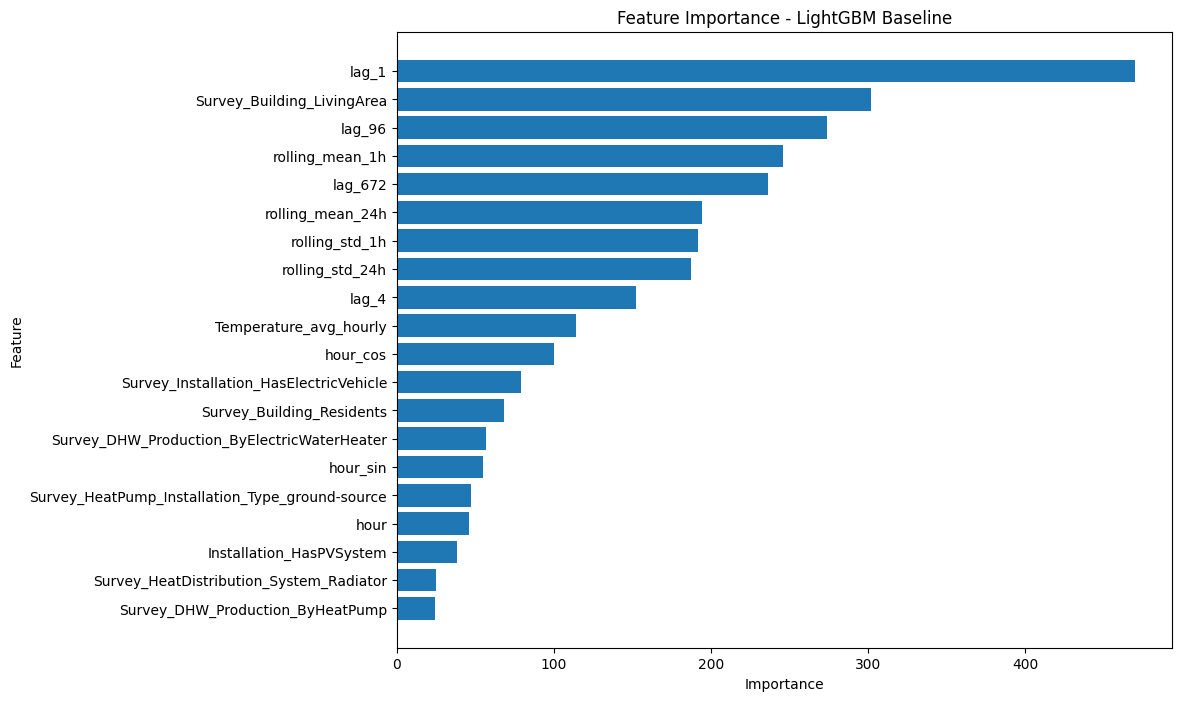

In [97]:
fi_baseline = plot_feature_importance(
    baseline_model,
    X_train.columns,
    "Feature Importance - LightGBM Baseline"
)

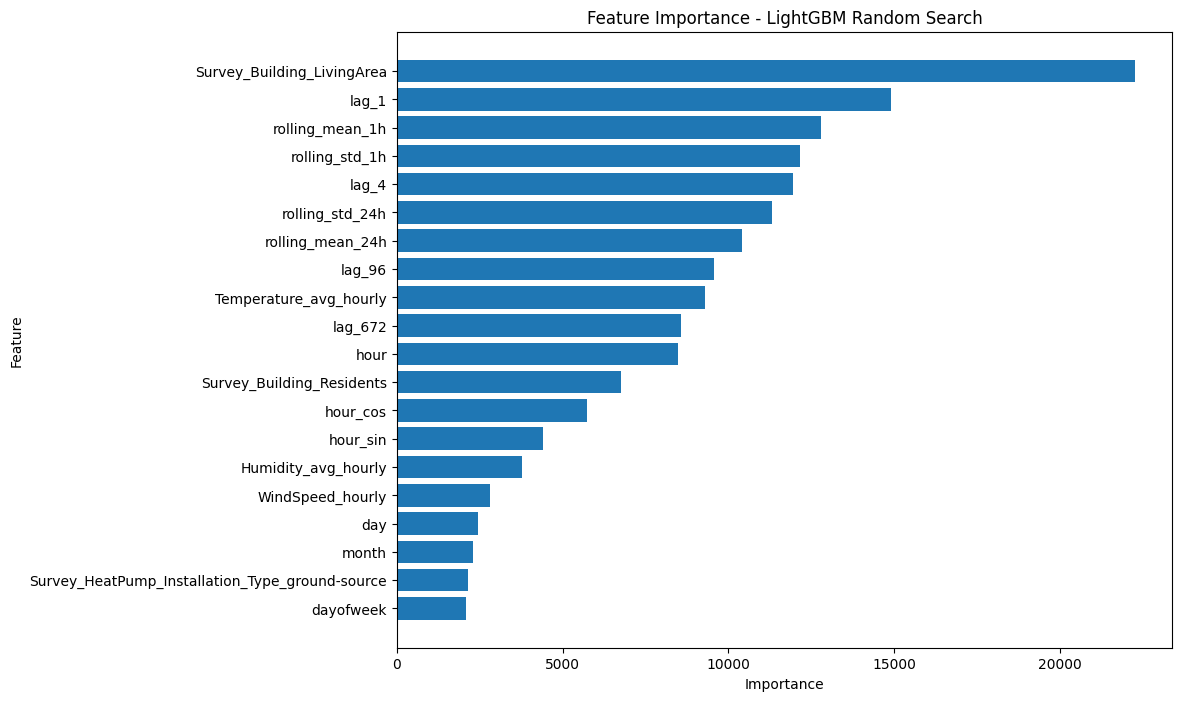

In [98]:
fi_random = plot_feature_importance(
    best_random,
    X_train.columns,
    "Feature Importance - LightGBM Random Search"
)

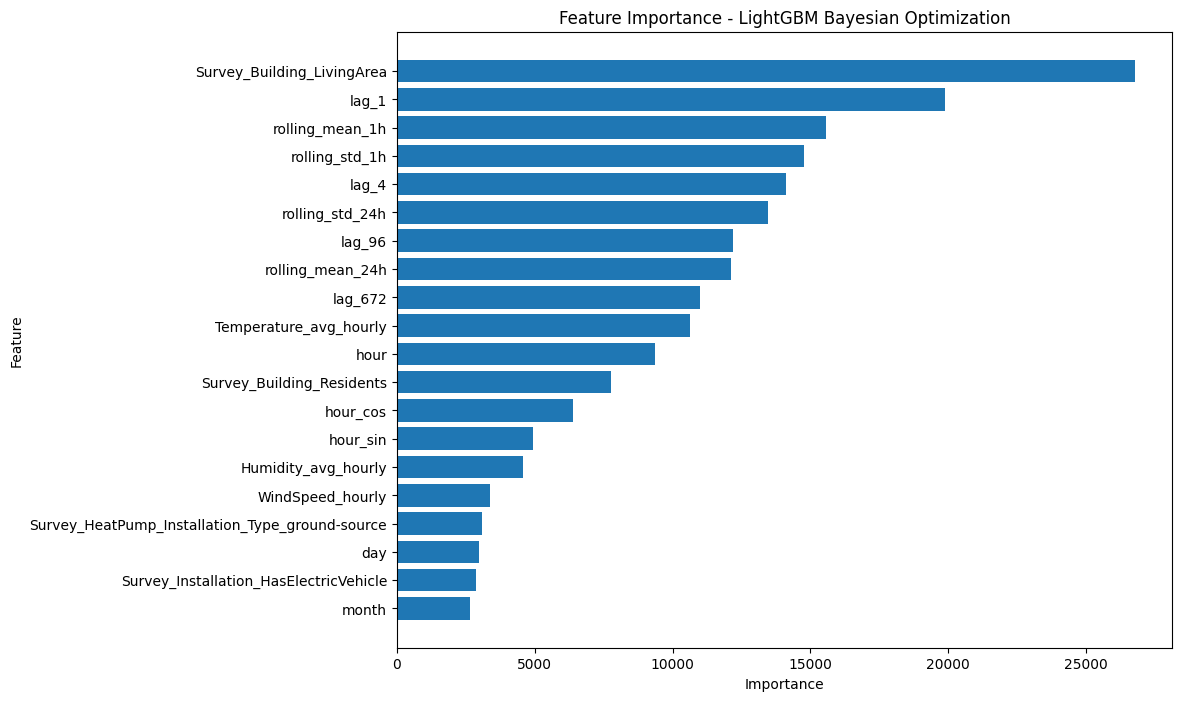

In [99]:
fi_bayes = plot_feature_importance(
    best_bayes,
    X_train.columns,
    "Feature Importance - LightGBM Bayesian Optimization"
)

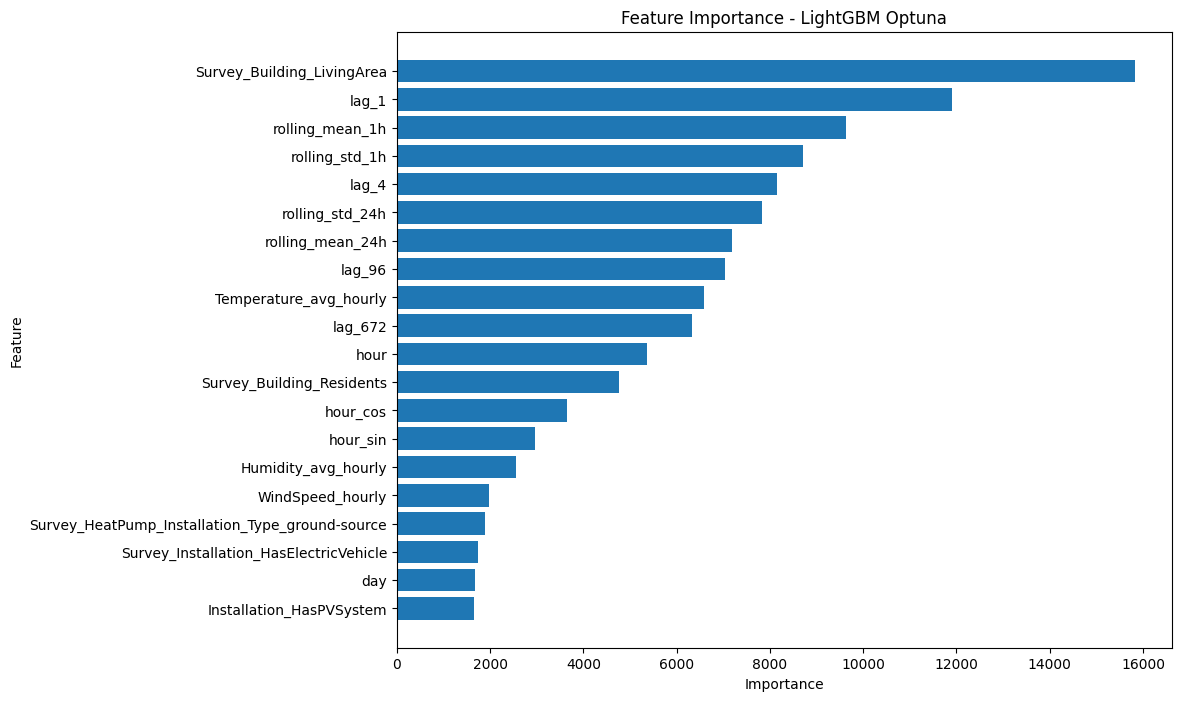

In [100]:
fi_optuna = plot_feature_importance(
    best_optuna,
    X_train.columns,
    "Feature Importance - LightGBM Optuna"
)

In [101]:
feature_importance_comparison = pd.DataFrame({

    "Baseline": fi_baseline["Feature"].values,

    "Random Search": fi_random["Feature"].values,

    "Bayesian": fi_bayes["Feature"].values,

    "Optuna": fi_optuna["Feature"].values

})


feature_importance_comparison

,Baseline,Random Search,Bayesian,Optuna
0,lag_1,Survey_Building_LivingArea,Survey_Building_LivingArea,Survey_Building_LivingArea
1,Survey_Building_LivingArea,lag_1,lag_1,lag_1
2,lag_96,rolling_mean_1h,rolling_mean_1h,rolling_mean_1h
3,rolling_mean_1h,rolling_std_1h,rolling_std_1h,rolling_std_1h
4,lag_672,lag_4,lag_4,lag_4
5,rolling_mean_24h,rolling_std_24h,rolling_std_24h,rolling_std_24h
6,rolling_std_1h,rolling_mean_24h,lag_96,rolling_mean_24h
7,rolling_std_24h,lag_96,rolling_mean_24h,lag_96
8,lag_4,Temperature_avg_hourly,lag_672,Temperature_avg_hourly
9,Temperature_avg_hourly,lag_672,Temperature_avg_hourly,lag_672


In [102]:
feature_importance_values = pd.DataFrame({

    "Feature": fi_optuna["Feature"].values,

    "Baseline": fi_baseline["Importance"].values,

    "Random Search": fi_random["Importance"].values,

    "Bayesian": fi_bayes["Importance"].values,

    "Optuna": fi_optuna["Importance"].values

})


feature_importance_values

,Feature,Baseline,Random Search,Bayesian,Optuna
0,Survey_Building_LivingArea,470,22266,26771,15828
1,lag_1,302,14908,19875,11897
2,rolling_mean_1h,274,12805,15554,9635
3,rolling_std_1h,246,12162,14750,8708
4,lag_4,236,11954,14097,8158
5,rolling_std_24h,194,11324,13450,7825
6,rolling_mean_24h,192,10420,12193,7181
7,lag_96,187,9557,12120,7033
8,Temperature_avg_hourly,152,9293,10989,6578
9,lag_672,114,8578,10624,6325


evaluasi dan analisis stabilitas model

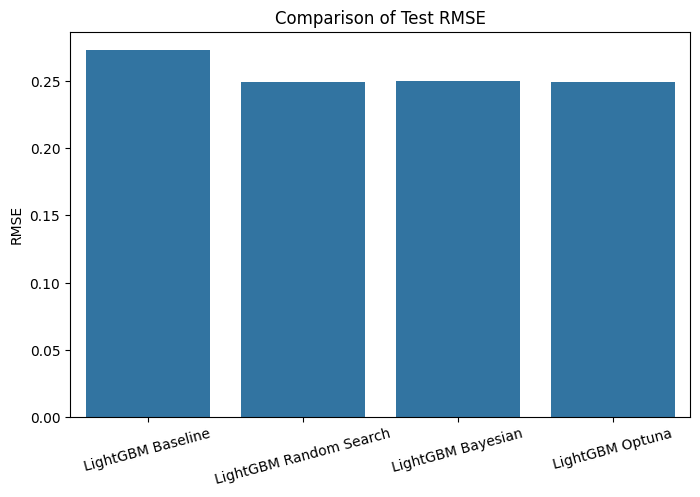

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Test_RMSE'
)

plt.title('Comparison of Test RMSE')
plt.ylabel('RMSE')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

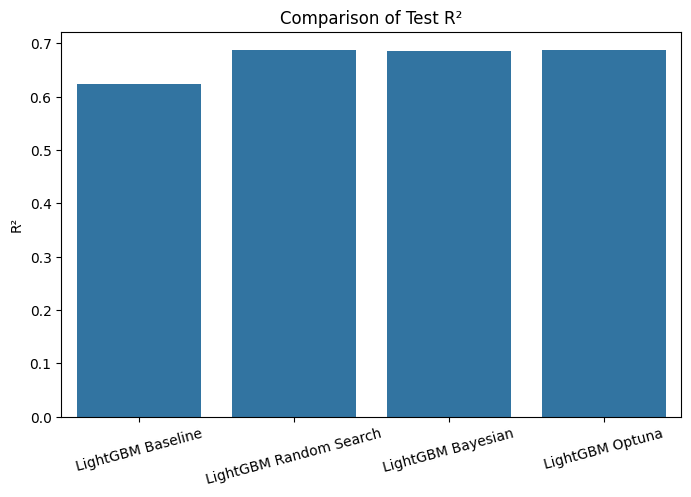

In [104]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Test_R2'
)

plt.title('Comparison of Test R²')
plt.ylabel('R²')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

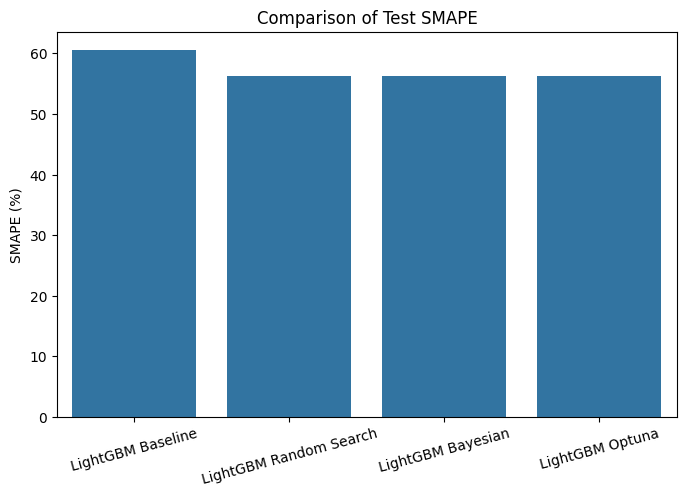

In [105]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Test_SMAPE'
)

plt.title('Comparison of Test SMAPE')
plt.ylabel('SMAPE (%)')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

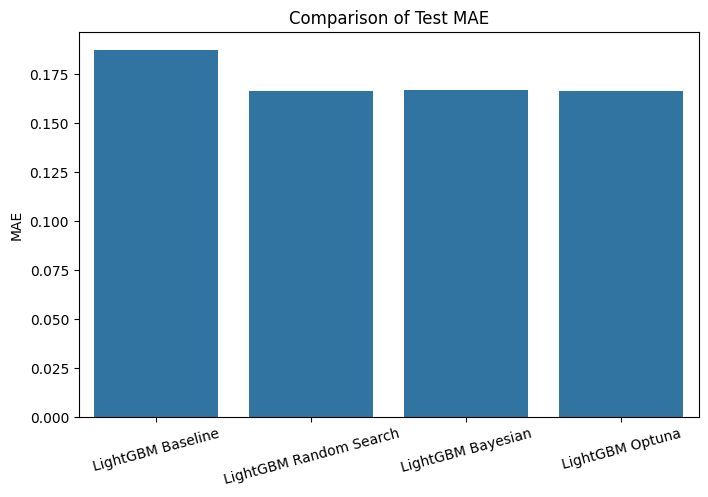

In [106]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Test_MAE'
)

plt.title('Comparison of Test MAE')
plt.ylabel('MAE')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

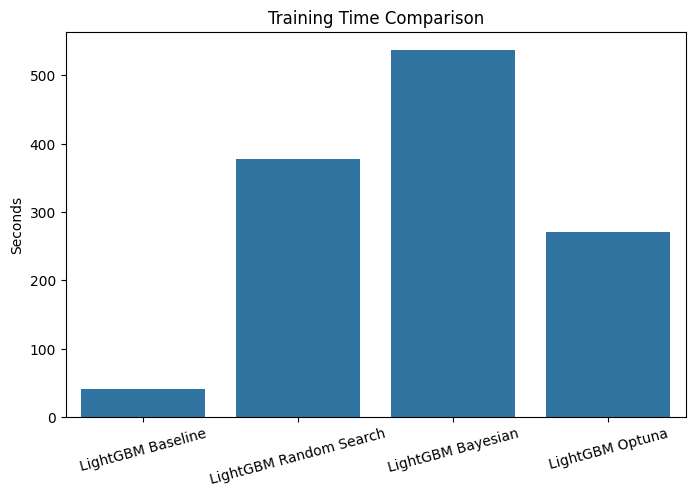

In [107]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Training_Time_sec'
)

plt.title('Training Time Comparison')
plt.ylabel('Seconds')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

In [108]:
tuning_plot = comparison.dropna(
    subset=['Tuning_Time_sec']
)

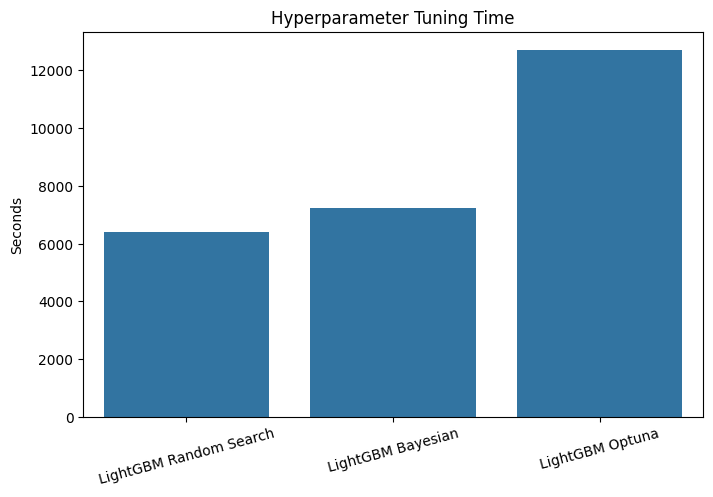

In [109]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=tuning_plot,
    x='Model',
    y='Tuning_Time_sec'
)

plt.title('Hyperparameter Tuning Time')
plt.ylabel('Seconds')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

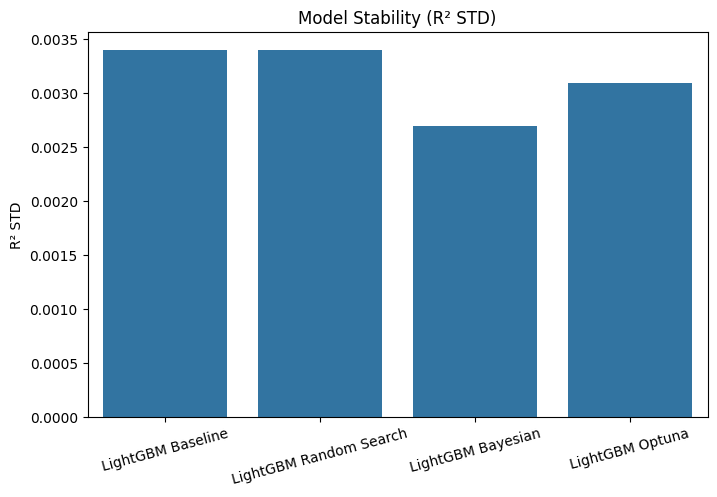

In [110]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=stability_comparison,
    x='Model',
    y='R2_STD'
)

plt.title('Model Stability (R² STD)')
plt.ylabel('R² STD')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

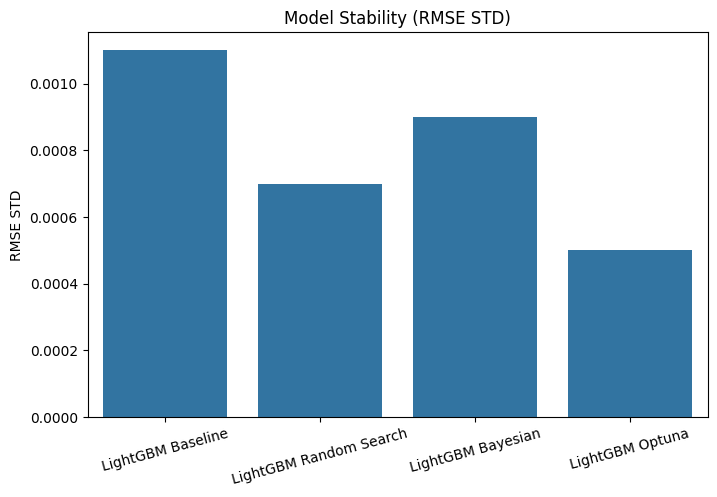

In [111]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=stability_comparison,
    x='Model',
    y='RMSE_STD'
)

plt.title('Model Stability (RMSE STD)')
plt.ylabel('RMSE STD')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

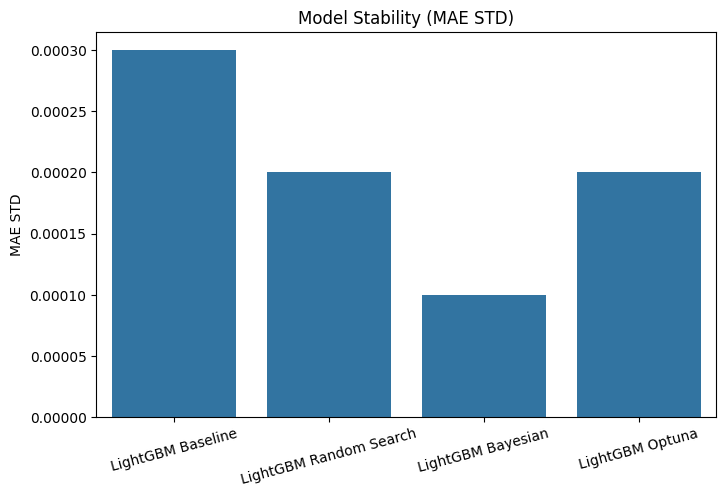

In [112]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=stability_comparison,
    x='Model',
    y='MAE_STD'
)

plt.title('Model Stability (MAE STD)')
plt.ylabel('MAE STD')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

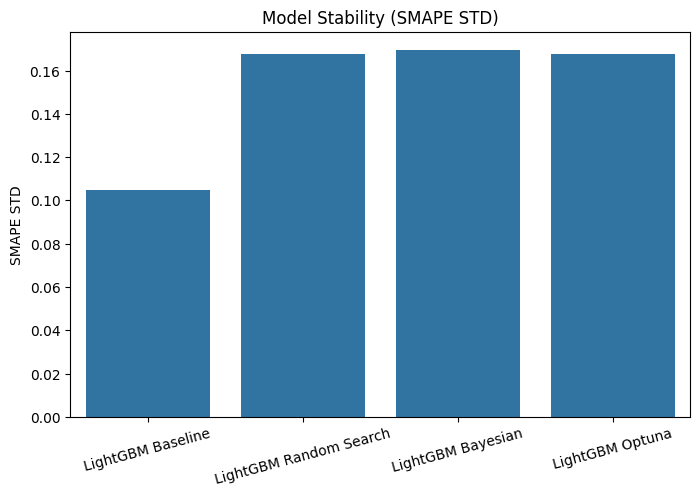

In [113]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=stability_comparison,
    x='Model',
    y='SMAPE_STD'
)

plt.title('Model Stability (SMAPE STD)')
plt.ylabel('SMAPE STD')
plt.xlabel('')

plt.xticks(rotation=15)
plt.show()

SIMPAN SELURUH HASIL

In [114]:
import os
import json
import joblib

In [115]:
# Membuat folder deployment

folders = [
    "deployment/models",
    "deployment/features",
    "deployment/parameters",
    "deployment/evaluation"
]


for folder in folders:
    os.makedirs(
        folder,
        exist_ok=True
    )


print("Folder deployment berhasil dibuat")

Folder deployment berhasil dibuat


In [116]:
joblib.dump(
    baseline_model,
    "deployment/models/lightgbm_baseline.pkl"
)

['deployment/models/lightgbm_baseline.pkl']

In [117]:
joblib.dump(
    best_random,
    "deployment/models/lightgbm_random_search.pkl"
)

['deployment/models/lightgbm_random_search.pkl']

In [118]:
joblib.dump(
    best_bayes,
    "deployment/models/lightgbm_bayesian.pkl"
)

['deployment/models/lightgbm_bayesian.pkl']

In [119]:
joblib.dump(
    best_optuna,
    "deployment/models/lightgbm_optuna.pkl"
)

['deployment/models/lightgbm_optuna.pkl']

In [120]:
joblib.dump(
    X_train.columns.tolist(),
    "deployment/features/feature_columns.pkl"
)

print("Feature columns berhasil disimpan")

Feature columns berhasil disimpan


In [121]:
baseline_params = baseline_model.get_params()


with open(
    "deployment/parameters/baseline_params.json",
    "w"
) as f:

    json.dump(
        baseline_params,
        f,
        indent=4,
        default=str
    )

In [122]:
random_params = best_random.get_params()


with open(
    "deployment/parameters/random_search_params.json",
    "w"
) as f:

    json.dump(
        random_params,
        f,
        indent=4,
        default=str
    )

In [123]:
bayes_params = best_bayes.get_params()


with open(
    "deployment/parameters/bayesian_params.json",
    "w"
) as f:

    json.dump(
        bayes_params,
        f,
        indent=4,
        default=str
    )

In [124]:
optuna_params = best_optuna.get_params()


with open(
    "deployment/parameters/optuna_params.json",
    "w"
) as f:

    json.dump(
        optuna_params,
        f,
        indent=4,
        default=str
    )

In [125]:
comparison.to_csv(
    "deployment/evaluation/model_comparison.csv",
    index=False
)

print("Evaluasi berhasil disimpan")

Evaluasi berhasil disimpan


In [126]:
feature_importance_comparison.to_csv(
    "deployment/evaluation/feature_importance.csv",
    index=False
)

print("Feature importance berhasil disimpan")

Feature importance berhasil disimpan


In [127]:
model_metadata = {

    "models": [
        "LightGBM Baseline",
        "LightGBM Random Search",
        "LightGBM Bayesian Optimization",
        "LightGBM Optuna"
    ],

    "task": "Regression",

    "objective": "regression",

    "boosting_type": "gbdt",

    "random_state": 42,

    "number_of_features": len(X_train.columns),

    "feature_source": "X_train.columns",

    "evaluation_metrics": [
        "MAE",
        "RMSE",
        "SMAPE",
        "R2"
    ]

}


with open(
    "deployment/model_metadata.json",
    "w"
) as f:

    json.dump(
        model_metadata,
        f,
        indent=4
    )


print("Metadata berhasil disimpan")

Metadata berhasil disimpan
